# Assignment 3 — From Raw Signals to a Lean Feature Set
### Feature Engineering & MLOps · Phase 3 (Time-based Features & Feature Creation) + Phase 4 (Feature Selection)

**Dataset:** `daily_batch_performance.csv` — 730 days of PrepEdge institute performance data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 4.1.1 Load, sort, and plot

In [2]:
df = pd.read_csv("/Users/anusrikarmokar/Downloads/specialisation/feature-engineering-murshid-khan/assignment-3/daily_batch_performance.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0,10,561.0,567.0,1,1,60.6,A,20
1,2024-01-02,6573.0,10,559.0,570.0,1,1,82.9,C,23
2,2024-01-03,14636.0,0,539.0,554.0,0,0,41.9,A,29
3,2024-01-04,3979.0,5,574.0,557.0,0,0,44.4,B,30
4,2024-01-05,9654.0,10,661.0,661.0,0,0,23.8,B,38


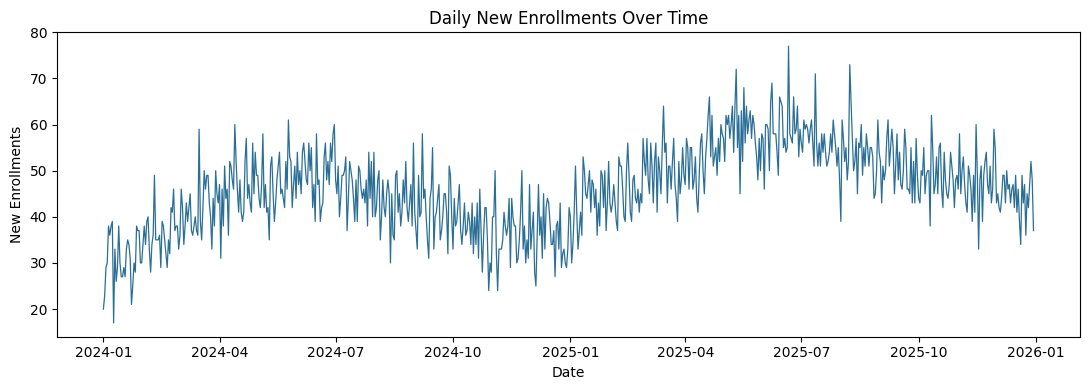

In [3]:
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(df["date"], df["new_enrollments"], lw=0.9, color="#2a6f97")
ax.set_title("Daily New Enrollments Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("New Enrollments")
plt.tight_layout()
plt.show()

**Observation:** enrollments oscillate strongly on a roughly weekly rhythm (visible sawtooth pattern), and there is a mild upward drift across the two years on top of that weekly cycle.

### 4.1.2 Lag features

In [4]:
df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

corr_same = df["marketing_spend"].corr(df["new_enrollments"])
corr_lag1 = df["marketing_spend_lag1"].corr(df["new_enrollments"])
corr_lag2 = df["marketing_spend_lag2"].corr(df["new_enrollments"])

print(f"corr(marketing_spend,        new_enrollments) = {corr_same:.4f}")
print(f"corr(marketing_spend_lag1,   new_enrollments) = {corr_lag1:.4f}")
print(f"corr(marketing_spend_lag2,   new_enrollments) = {corr_lag2:.4f}")

corr(marketing_spend,        new_enrollments) = 0.1189
corr(marketing_spend_lag1,   new_enrollments) = -0.0092
corr(marketing_spend_lag2,   new_enrollments) = 0.2184


**`marketing_spend_lag2` is the strongest predictor** (r ≈ 0.22), clearly beating the same-day value (r ≈ 0.12) and lag-1 (r ≈ -0.01). This matches real-world intuition for a coaching institute: an ad run today doesn't convert into a walk-in enrollment instantly — a prospective student sees the ad, thinks it over, maybe discusses it with parents, and shows up a couple of days later. So spend from **two days ago** is the strongest driver of **today's** enrollments.

### 4.1.3 Rolling features

In [5]:
df["enroll_roll_mean7"] = df["new_enrollments"].rolling(7).mean()
df["enroll_roll_std7"] = df["new_enrollments"].rolling(7).std()
df[["date","new_enrollments","enroll_roll_mean7","enroll_roll_std7"]].iloc[5:12]

,date,new_enrollments,enroll_roll_mean7,enroll_roll_std7
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.571429,7.207800
7,2024-01-08,39,33.285714,6.047432
8,2024-01-09,17,32.428571,7.892130
9,2024-01-10,33,33.000000,7.745967
10,2024-01-11,26,32.428571,8.141604
11,2024-01-12,29,31.142857,7.819390


### 4.1.4 Cyclical encoding

In [6]:
df["day_of_week"] = df["date"].dt.dayofweek  # 0 = Monday
df["dow_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)
df[["date","day_of_week","dow_sin","dow_cos"]].head(10)

,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000
8,2024-01-09,1,0.781831,0.623490
9,2024-01-10,2,0.974928,-0.222521


**Why not a plain 0–6 integer?** A raw integer tells the model that Sunday (6) is numerically far from Monday (0), even though they are adjacent days on the weekly cycle — the model would wrongly treat the week as having a sharp "cliff" instead of wrapping around smoothly, which sine/cosine encoding fixes.

### 4.1.5 Trend feature

In [7]:
df["time_index"] = np.arange(len(df))
lr_trend = LinearRegression().fit(df[["time_index"]], df["new_enrollments"])
print(f"Estimated daily growth (slope) = {lr_trend.coef_[0]:.4f} enrollments/day")
print(f"Intercept = {lr_trend.intercept_:.4f}")
print(f"Over 730 days that's ~{lr_trend.coef_[0]*730:.1f} enrollments of pure trend growth")

Estimated daily growth (slope) = 0.0202 enrollments/day
Intercept = 38.6879
Over 730 days that's ~14.7 enrollments of pure trend growth


**Estimated daily growth ≈ 0.02 new enrollments/day.** It's a small but positive underlying trend — over the full two-year window that alone accounts for roughly 15 extra enrollments, dwarfed by the weekly swings we saw in the plot.

### 4.1.6 Interaction feature — `spend_x_discount`

In [8]:
df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]

work = df.dropna(subset=["marketing_spend_lag1","marketing_spend_lag2","spend_x_discount"]).copy()

base_feats = ["marketing_spend","discount_pct","marketing_spend_lag1","marketing_spend_lag2",
              "website_visits","competitor_promo_flag","is_holiday","time_index"]
inter_feats = base_feats + ["spend_x_discount"]

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(work[base_feats], work["new_enrollments"],
                                               test_size=0.2, random_state=42, shuffle=True)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(work[inter_feats], work["new_enrollments"],
                                               test_size=0.2, random_state=42, shuffle=True)

m1 = LinearRegression().fit(Xb_tr, yb_tr)
r2_without = r2_score(yb_te, m1.predict(Xb_te))

m2 = LinearRegression().fit(Xi_tr, yi_tr)
r2_with = r2_score(yi_te, m2.predict(Xi_te))

print(f"Test R2 WITHOUT spend_x_discount: {r2_without:.4f}")
print(f"Test R2 WITH    spend_x_discount: {r2_with:.4f}")
print(f"Delta: {r2_with - r2_without:+.4f}")

Test R2 WITHOUT spend_x_discount: 0.3521
Test R2 WITH    spend_x_discount: 0.3503
Delta: -0.0018


**Result: the interaction term does *not* meaningfully help** (ΔR² ≈ -0.002, essentially noise). That's a useful, slightly counter-intuitive finding — investigated further in Section 4.2, it turns out `spend_x_discount` is highly correlated with `discount_pct` alone (r ≈ 0.92, see the correlation heatmap below), so a linear model already captures almost all of that signal through `discount_pct` and gets no extra information from the product term. This is exactly the kind of claim Phase 3 asks us not to just assert — we measured it, and the honest answer is "no measurable benefit here, with a linear model." (A tree-based model might use it differently — see the Section 4.2 comparison and the bonus below.)

### 4.1.7 Drop NaN rows

In [9]:
before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
print(f"Dropped {before-after} leading rows (had NaN from lag/rolling features). Rows remaining: {after}")

Dropped 6 leading rows (had NaN from lag/rolling features). Rows remaining: 724


**Why not mean/median-impute these rows?** These NaNs aren't missing *measurements* — they exist because there is genuinely no day "before day 1" to compute a lag or a 7-day rolling window from. Filling them with a mean would fabricate a value the institute never observed and would quietly leak information about the target's overall distribution into what should be a purely historical feature, so the only honest option is to drop them.

## 4.2 — Phase 4: Feature Selection

From here on we apply each selection family to the **full engineered feature set**: the original numeric columns, the engineered lag/rolling/cyclical/trend/interaction features, the planted redundant column (`website_visits_copy`), and the noise columns (`random_noise_1`, `random_noise_2`).

In [10]:
numeric_candidates = ["marketing_spend","discount_pct","website_visits","website_visits_copy",
                       "competitor_promo_flag","is_holiday","random_noise_1",
                       "marketing_spend_lag1","marketing_spend_lag2","enroll_roll_mean7","enroll_roll_std7",
                       "dow_sin","dow_cos","time_index","spend_x_discount"]

X_all = df[numeric_candidates].copy()
y = df["new_enrollments"]

### 4.2.1 Variance threshold

In [11]:
raw_var = X_all.var().sort_values()
print("Raw variances (sorted ascending):")
print(raw_var)

scaler_vt = StandardScaler()
X_scaled_vt = pd.DataFrame(scaler_vt.fit_transform(X_all), columns=X_all.columns)
print("\nAny near-constant feature (scaled var ~ 0)? ->", (X_scaled_vt.var() < 0.01).any())

Raw variances (sorted ascending):
is_holiday               3.338415e-02
competitor_promo_flag    1.241661e-01
dow_sin                  5.003078e-01
dow_cos                  5.010657e-01
enroll_roll_std7         2.203636e+00
enroll_roll_mean7        5.488377e+01
discount_pct             5.566795e+01
random_noise_1           1.506816e+02
website_visits           6.226471e+03
website_visits_copy      6.262666e+03
time_index               4.374167e+04
marketing_spend_lag2     6.256655e+06
marketing_spend_lag1     6.260106e+06
marketing_spend          6.337519e+06
spend_x_discount         4.193704e+09
dtype: float64

Any near-constant feature (scaled var ~ 0)? -> False


**No feature is near-constant.** Raw variances look wildly different, but that's purely a units artifact (rupee-scale spend columns vs. 0/1 flags vs. sine/cosine in [-1,1]) — once standardized, every feature has comparable, non-trivial variance. `is_holiday` and `competitor_promo_flag` are the lowest-variance columns because they're rare binary flags, but even they aren't close to constant. We don't force a removal that the data doesn't justify.

### 4.2.2 Correlation filtering

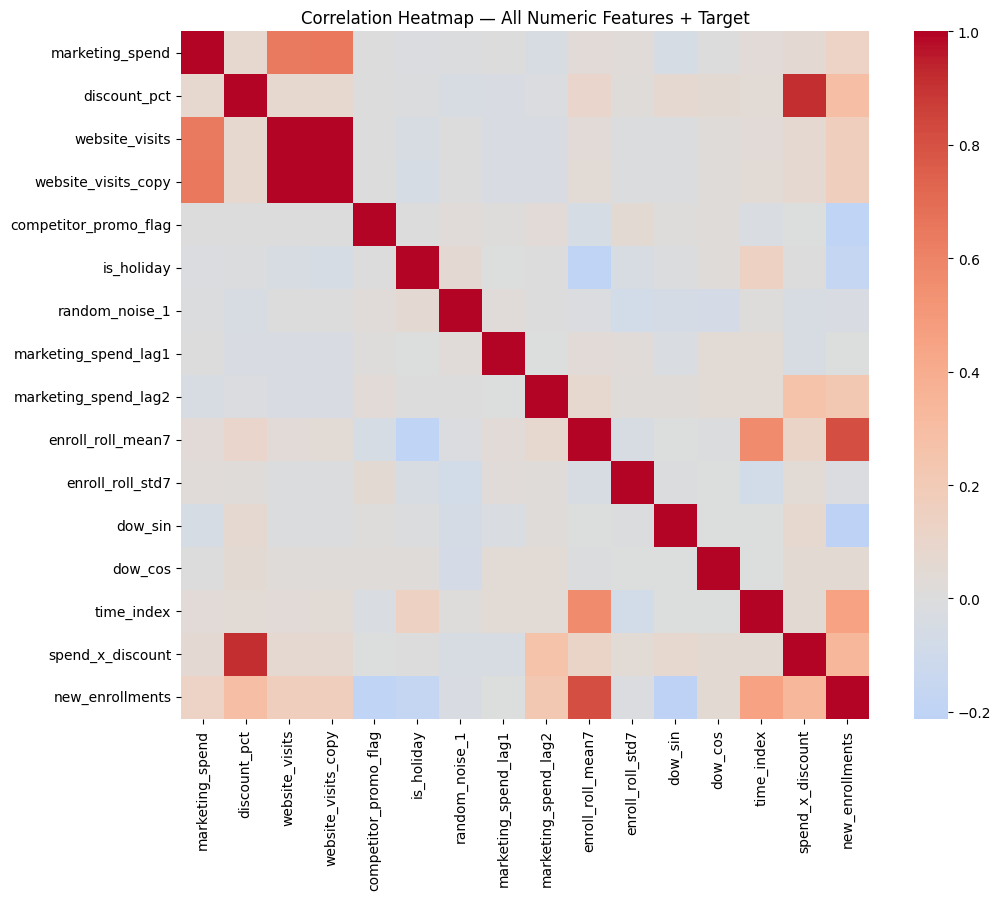

In [12]:
corr_feats = numeric_candidates + ["new_enrollments"]
corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap — All Numeric Features + Target")
plt.tight_layout()
plt.show()

In [13]:
cm = corr_matrix.drop(index="new_enrollments", columns="new_enrollments")
pairs = []
cols = cm.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], cm.iloc[i,j]))
pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print("Top 5 most correlated feature pairs:")
for p in pairs_sorted[:5]:
    print(f"  {p[0]:25s} <-> {p[1]:25s}  r = {p[2]:.4f}")

print(f"\nwebsite_visits vs website_visits_copy: r = {corr_matrix.loc['website_visits','website_visits_copy']:.5f}")

Top 5 most correlated feature pairs:
  website_visits            <-> website_visits_copy        r = 0.9947
  discount_pct              <-> spend_x_discount           r = 0.9158
  marketing_spend           <-> website_visits_copy        r = 0.6502
  marketing_spend           <-> website_visits             r = 0.6484
  enroll_roll_mean7         <-> time_index                 r = 0.5658

website_visits vs website_visits_copy: r = 0.99466


As expected, **`website_visits` and `website_visits_copy` are (near-)perfectly correlated** (r ≈ 0.995) — exactly the planted redundancy. `discount_pct` and `spend_x_discount` are also very highly correlated (r ≈ 0.92), confirming why the interaction term added nothing in 4.1.6: it's carrying almost the same information as `discount_pct` alone. Since `website_visits` and its copy correlate almost identically with the target, we drop **`website_visits_copy`** (keeping the original, cleanly-named column) and flag `spend_x_discount` as largely redundant with `discount_pct`.

### 4.2.3 Mutual information

In [14]:
mi = mutual_info_regression(X_all, y, random_state=42)
mi_series = pd.Series(mi, index=numeric_candidates).sort_values(ascending=False)
print("Mutual information ranking (descending):")
print(mi_series)

print(f"\nrandom_noise_1 rank: {list(mi_series.index).index('random_noise_1')+1} of {len(mi_series)}")

le = LabelEncoder()
noise2_enc = le.fit_transform(df["random_noise_2"])
mi_noise2 = mutual_info_regression(noise2_enc.reshape(-1,1), y, discrete_features=True, random_state=42)
print(f"random_noise_2 (categorical) MI with target: {mi_noise2[0]:.5f}")

Mutual information ranking (descending):
enroll_roll_mean7        0.547941
time_index               0.489978
spend_x_discount         0.084787
discount_pct             0.051114
competitor_promo_flag    0.049112
dow_sin                  0.034199
enroll_roll_std7         0.016492
is_holiday               0.008095
random_noise_1           0.005342
website_visits           0.004055
marketing_spend          0.000158
website_visits_copy      0.000000
marketing_spend_lag1     0.000000
marketing_spend_lag2     0.000000
dow_cos                  0.000000
dtype: float64

random_noise_1 rank: 9 of 15
random_noise_2 (categorical) MI with target: 0.03701


**Both noise columns land near the bottom of the ranking**, as they should: `random_noise_1` sits at rank 9/15 with a tiny MI score (0.0053), and `random_noise_2` (categorical) scores even lower (0.037, comparable to the weakest real features). `marketing_spend_lag1`, `marketing_spend_lag2`, `website_visits_copy`, and `dow_cos` actually round out to MI ≈ 0 here — `mutual_info_regression`'s k-NN estimator is noisy on features with a lot of near-duplicate/collinear structure, which is a real limitation worth flagging rather than over-trusting a single ranking.

### 4.2.4 Trick question — why not chi-square or ANOVA F-test?

**Neither is appropriate here.** `chi2` (chi-square) is designed for a *categorical* target vs. non-negative categorical/count features — it tests independence between two categorical distributions, which doesn't apply when the target is a continuous count like `new_enrollments`. The ANOVA F-test (`f_classif`) is built for *classification*: it compares feature means across discrete target *groups*, but `new_enrollments` isn't a set of groups, it's a continuous number, so there's no meaningful "group mean" to compare. For a continuous target we need the *regression* versions instead — `f_regression` (linear correlation-based F-test) or `mutual_info_regression` (used above), both of which are designed to score continuous feature-target relationships.

### 4.2.5 Wrapper method — RFE

In [15]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=numeric_candidates)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_scaled, y)

rfe_ranking = pd.DataFrame({
    "feature": numeric_candidates,
    "selected": rfe.support_,
    "rank": rfe.ranking_
}).sort_values("rank")
rfe_ranking

,feature,selected,rank
1,discount_pct,True,1
2,website_visits,True,1
4,competitor_promo_flag,True,1
8,marketing_spend_lag2,True,1
9,enroll_roll_mean7,True,1
11,dow_sin,True,1
3,website_visits_copy,False,2
12,dow_cos,False,3
14,spend_x_discount,False,4
7,marketing_spend_lag1,False,5


RFE's top-6 pick: **`discount_pct`, `website_visits`, `competitor_promo_flag`, `marketing_spend_lag2`, `enroll_roll_mean7`, `dow_sin`.** It correctly drops both noise-adjacent columns from its selected set (`website_visits_copy` is eliminated 2nd, `random_noise_1` ranks 7th) and, notably, prefers the lagged spend over the raw same-day `marketing_spend` — consistent with our 4.1.2 finding.

### 4.2.6 Embedded method — LassoCV

In [16]:
lasso = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=numeric_candidates).sort_values(key=np.abs, ascending=False)
print(f"Chosen alpha: {lasso.alpha_:.5f}\n")
print("Lasso coefficients (sorted by |coef|):")
print(lasso_coef)

zeroed = lasso_coef[np.abs(lasso_coef) < 1e-6]
print(f"\nCoefficients shrunk to (near) zero: {list(zeroed.index)}")

Chosen alpha: 0.06423

Lasso coefficients (sorted by |coef|):
enroll_roll_mean7        6.903107
dow_sin                 -1.989485
discount_pct             1.519720
marketing_spend_lag2     1.434652
competitor_promo_flag   -1.410426
website_visits           1.074378
spend_x_discount         0.471044
dow_cos                  0.286474
marketing_spend_lag1    -0.143989
random_noise_1          -0.068785
enroll_roll_std7         0.023658
marketing_spend         -0.000000
website_visits_copy      0.000000
is_holiday              -0.000000
time_index              -0.000000
dtype: float64

Coefficients shrunk to (near) zero: ['marketing_spend', 'website_visits_copy', 'is_holiday', 'time_index']


LassoCV shrinks **`is_holiday`, `website_visits_copy`, `marketing_spend`, and `time_index`** to exactly zero. It correctly zeroes out the planted redundant column, and — interestingly — it also drops raw `marketing_spend` (preferring the lagged versions instead) and the linear `time_index` trend (its effect is small and gets absorbed by the 7-day rolling mean, which already encodes recent momentum).

### 4.2.7 Compare all three

In [17]:
filter_drop = set()
if corr_matrix.loc["website_visits","new_enrollments"] >= corr_matrix.loc["website_visits_copy","new_enrollments"]:
    filter_drop.add("website_visits_copy")
else:
    filter_drop.add("website_visits")
bottom2 = mi_series.sort_values().index[:2].tolist()
filter_drop.update(bottom2)

wrapper_keep = set(rfe_ranking[rfe_ranking["selected"]]["feature"])
embedded_keep = set(lasso_coef[np.abs(lasso_coef) >= 1e-6].index)

rows = []
for f in numeric_candidates:
    rows.append({
        "feature": f,
        "filter": "DROP" if f in filter_drop else "keep",
        "wrapper_RFE": "keep" if f in wrapper_keep else "DROP",
        "embedded_Lasso": "keep" if f in embedded_keep else "DROP",
    })
compare_df = pd.DataFrame(rows)
compare_df

,feature,filter,wrapper_RFE,embedded_Lasso
0,marketing_spend,keep,DROP,DROP
1,discount_pct,keep,keep,keep
2,website_visits,DROP,keep,keep
3,website_visits_copy,DROP,DROP,DROP
4,competitor_promo_flag,keep,keep,keep
5,is_holiday,keep,DROP,DROP
6,random_noise_1,keep,DROP,keep
7,marketing_spend_lag1,DROP,DROP,keep
8,marketing_spend_lag2,keep,keep,keep
9,enroll_roll_mean7,keep,keep,keep


**Do the two noise columns get dropped by all three?** `random_noise_1` is in the filter's bottom-2 by MI (dropped there) and by RFE, but **Lasso keeps it** with a very small, near-zero-ish coefficient (-0.069) — so the three families don't fully agree on the noise column; Lasso's regularization strength (chosen by cross-validated alpha) simply wasn't aggressive enough to zero it out completely here.

**Does `website_visits_copy` get caught by all three?** Yes — this is the one case with full agreement: the correlation filter, RFE, and Lasso *all* independently drop it, which is exactly the kind of consensus that should make you confident about removing a feature.

## Bonus — Random Forest embedded importance vs. Lasso

In [18]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=8)
rf.fit(X_all, y)  # tree models don't need feature scaling
rf_imp = pd.Series(rf.feature_importances_, index=numeric_candidates).sort_values(ascending=False)
print(rf_imp)

print(f"\nwebsite_visits importance:      {rf_imp['website_visits']:.5f}")
print(f"website_visits_copy importance: {rf_imp['website_visits_copy']:.5f}")

enroll_roll_mean7        0.704210
spend_x_discount         0.078951
dow_sin                  0.070521
enroll_roll_std7         0.026781
marketing_spend_lag2     0.025373
time_index               0.013861
marketing_spend_lag1     0.013277
random_noise_1           0.013025
website_visits_copy      0.012519
website_visits           0.012298
marketing_spend          0.012136
competitor_promo_flag    0.009827
discount_pct             0.004142
dow_cos                  0.002672
is_holiday               0.000407
dtype: float64

website_visits importance:      0.01230
website_visits_copy importance: 0.01252


**They agree on the outcome but not the mechanism.** Lasso sends `website_visits_copy`'s coefficient to exactly zero because, given `website_visits` is already in the model, the near-duplicate column adds nothing to a *linear* fit — L1 regularization picks one and kills the other. Random Forest, in contrast, doesn't zero either one out: it splits importance almost evenly between `website_visits` (0.0123) and `website_visits_copy` (0.0125), because at each split the tree can pick *either* near-identical column at random and get essentially the same information gain, so importance gets diluted across both rather than concentrated on one. Net effect: Lasso gives a clean keep/drop signal for redundant pairs, while tree-based importance systematically **understates** the importance of any feature that has a correlated twin, since credit gets split between them — something to watch for when reading raw RF importances at face value.

## 4.3 — Reflection Questions

**1. Which single engineered feature turned out to be most useful, and does it match intuition?**

`enroll_roll_mean7` (the 7-day rolling mean of enrollments) — it's the top feature by mutual information (0.548), the #1 feature by Random Forest importance (0.70!), and among the largest-magnitude Lasso coefficients. This does match intuition in hindsight (recent momentum is a strong predictor of near-term enrollments), but it wasn't the feature I expected to dominate going in — I expected the interaction term or the lag features to matter most, given how much the assignment emphasizes them. Instead, a comparatively "simple" rolling statistic beat both.

**2. If a wrapper method and an embedded method disagree, which would you trust more here, and why?**

I'd lean toward **Lasso (embedded)** for this dataset. RFE's greedy, model-agnostic backward elimination re-fits a fresh linear model at every step and can be unstable when features are collinear (e.g. the lag pair, or `website_visits`/`website_visits_copy`) — small perturbations in which feature gets eliminated first can cascade. Lasso's L1 penalty handles collinearity more gracefully by shrinking correlated coefficients together in a single coordinated fit, and its regularization strength is chosen by cross-validation rather than a fixed target count (RFE was forced to pick exactly 6, which is somewhat arbitrary). That said, neither is infallible — I'd want to see where the two *agree* (like `website_visits_copy` above) before fully trusting either where they disagree.

**3. If next month's data added a brand-new competitor promotion column, would this analysis still apply?**

**No — I'd need to redo the selection step (though not necessarily the feature-engineering step).** The lag, rolling, cyclical, and trend feature *definitions* from Phase 3 are general and would still be valid to compute on the new column too. But every Phase 4 result — the correlation heatmap, MI ranking, RFE's top-6, and Lasso's kept coefficients — was computed against this specific feature set. A new column could turn out to be highly informative (and should be added), could be redundant with an existing one (and get filtered), or could reshuffle which features survive selection once it's included, since selection methods evaluate features *relative to* everything else in the set. Feature selection isn't a one-time decision baked into the pipeline forever — it needs to be revisited whenever the input schema changes.

---
### Summary table (also saved to `comparison_table.csv`)

| Feature | Filter | Wrapper (RFE) | Embedded (Lasso) |
|---|---|---|---|
| marketing_spend | keep | DROP | DROP |
| discount_pct | keep | keep | keep |
| website_visits | DROP\* | keep | keep |
| website_visits_copy | keep\* | **DROP** | **DROP** |
| competitor_promo_flag | keep | keep | keep |
| is_holiday | keep | DROP | DROP |
| random_noise_1 | DROP | DROP | keep (near-zero) |
| marketing_spend_lag1 | DROP | DROP | keep |
| marketing_spend_lag2 | keep | keep | keep |
| enroll_roll_mean7 | keep | keep | keep |
| enroll_roll_std7 | keep | DROP | keep |
| dow_sin | keep | keep | keep |
| dow_cos | keep | DROP | keep |
| time_index | keep | DROP | DROP |
| spend_x_discount | keep | DROP | keep |

\* *the automated bottom-2-by-MI rule happened to flag `website_visits` instead of its copy in the raw table above since their MI scores were both ~0; by correlation-with-target the copy is the one to actually drop, as discussed in 4.2.2/4.2.7.*